# Bayesian Neural Networks

Neural networks are powerful approximators. However, standard approaches for learning this approximators does not take into account the inherent uncertainty we may have when fitting a model.

In [1]:
%pip install -q numpyro jax jaxlib matplotlib numpy optax

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal
import optax

/Users/helgel/Documents/Work/Forelesninger/Variational-show/ProbAI/ProbAI26/python/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


/Users/helgel/Documents/Work/Forelesninger/Variational-show/ProbAI/ProbAI26/python/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

We use some fake data. As neural nets of even one hidden layer
can be universal function approximators, we can see if we can
train a simple neural network to fit a noisy sinusoidal data, like this:


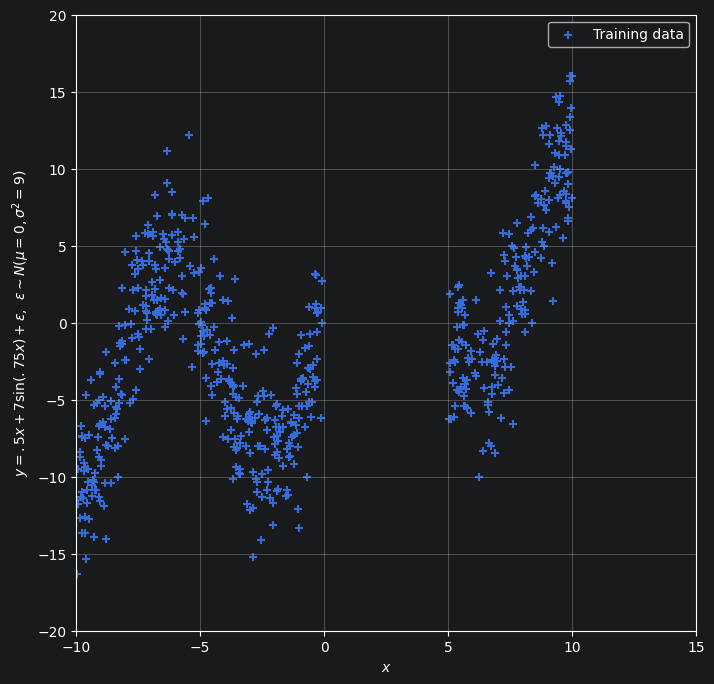

In [2]:
# Use numpy for data generation (unchanged)
np.random.seed(42)

def gold_standard(x):
    return .5 * x + 7. * np.sin(0.75 * x)

NSAMPLE = 600
x_train = np.concatenate(
    (np.random.uniform(-10, 0, ((2 * NSAMPLE)//3, 1)), np.random.uniform(5, 10, (NSAMPLE - (2 * NSAMPLE)//3, 1))),
    axis=0)
y_train = gold_standard(x_train) + np.random.normal(size=(NSAMPLE, 1), scale=3.0)
x_test = np.arange(-20, 15, 0.05).reshape(-1, 1)

# Convert to JAX arrays (replaces torch.tensor)
x_train = jnp.array(x_train, dtype=jnp.float32)
y_train = jnp.array(y_train, dtype=jnp.float32)
x_test  = jnp.array(x_test,  dtype=jnp.float32)

# Plot it. Notice the gap in observations
plt.figure(figsize=(8, 8))
plt.scatter(np.array(x_train), np.array(y_train), marker='+', label='Training data')
plt.xlabel("$x$")
plt.ylabel("$y = .5x + 7\\sin(.75x) + \\epsilon$,  "
           "$\\epsilon\\sim N (\\mu=0, \\sigma^2=9)$")
plt.xlim([-10, 15])
plt.ylim([-20, 20])
plt.grid(True, "both")
plt.legend()

## Training a neural network

We employ a simple feedforward network with `NHIDDEN` hidden units to try to fit the data.

<center>
<img src="./BNNs-plain.png" alt="Drawing" height="250">
</center>



In [3]:
# Standard neural network using JAX (replaces torch.nn.Parameter with jnp arrays + optax)
from jax import grad, jit

def nn_predict(params, x_data):
    w, b, w_out, b_out = params['w'], params['b'], params['w_out'], params['b_out']
    hidden = jnp.tanh(x_data @ w + b)
    return hidden @ w_out + b_out

def mse_loss(params, x, y):
    y_pred = nn_predict(params, x)
    return jnp.sum((y_pred - y) ** 2)

NHIDDEN = 250
key = jax.random.PRNGKey(42)
keys = jax.random.split(key, 4)
params = {
    'w':     jax.random.normal(keys[0], (1, NHIDDEN)) * 0.05,
    'b':     jax.random.normal(keys[1], (1, NHIDDEN)) * 0.05,
    'w_out': jax.random.normal(keys[2], (NHIDDEN, 1)) * 0.05,
    'b_out': jax.random.normal(keys[3], (1, 1))       * 0.05,
}

num_iterations = 10000
optimizer = optax.adam(0.01)
opt_state = optimizer.init(params)

@jit
def step(params, opt_state, x, y):
    loss, grads = jax.value_and_grad(mse_loss)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

for j in range(num_iterations + 1):
    params, opt_state, loss = step(params, opt_state, x_train, y_train)
    if j % 1000 == 0:
        print("[iteration %05d] loss: %12.2f" % (j, loss.item()))

[iteration 00000] loss:     26809.77
[iteration 01000] loss:      5089.51
[iteration 02000] loss:      5058.38
[iteration 03000] loss:      5037.57
[iteration 04000] loss:      5021.25
[iteration 05000] loss:      5012.23
[iteration 06000] loss:      5006.55
[iteration 07000] loss:      5001.13
[iteration 08000] loss:      4991.36
[iteration 09000] loss:      4975.60
[iteration 10000] loss:      4955.31


### Results:
We see that the neural network can fit this sinusoidal data quite well, as expected. However, notice the behavour around the gap in the data. 

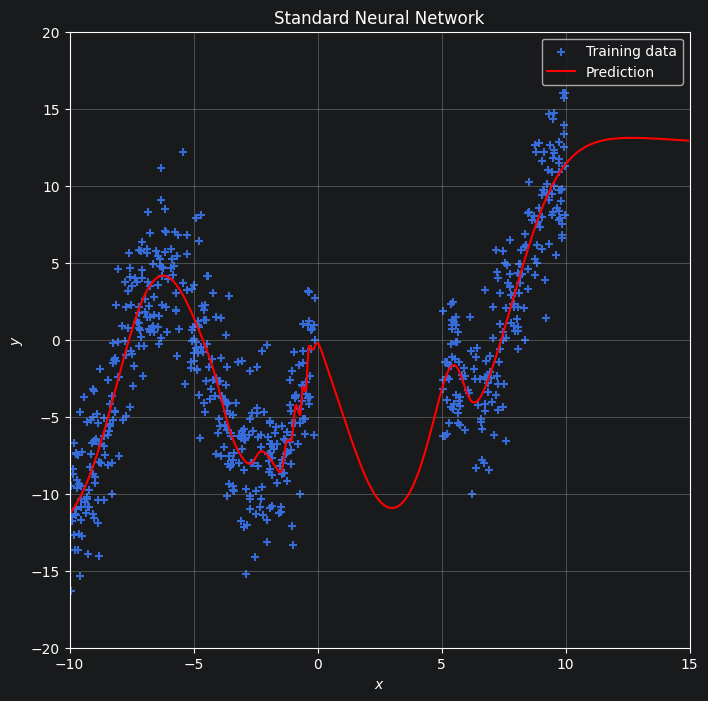

In [4]:
y_test = nn_predict(params, x_test)

plt.figure(figsize=(8, 8))
plt.scatter(np.array(x_train), np.array(y_train), marker='+', label='Training data')
plt.plot(np.array(x_test), np.array(y_test), 'r-', label='Prediction')
plt.title('Standard Neural Network')
plt.legend()
plt.xticks(np.arange(-10, 16, 5))
plt.yticks(np.arange(-20, 21, 5))
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.xlim([-10, 15])
plt.ylim([-20, 20])
plt.grid(True, "both")

However this model is unable to capture the uncertainty in the model. For example, when making predictions about a single point (e.g. around $x=2.5$) we can see we do not account aobut the inherent noise there is in this predictions or the uncertainty about what the model should actually be in this area. In the next section, we will see what happen when we introduce a Bayesian approach using

## Bayesian Learning of Neural Networks

[Bayesian modeling](https://mlg.eng.cam.ac.uk/zoubin/papers/NatureReprint15.pdf) offers a systematic framework for reasoning about model uncertainty. Instead of just learning point estimates, we're going to learn a distribution over models that are consistent with the observed data.

In Bayesian learning, the weights of the network are **random variables**. The output of the nework is also a **random variable**. The random variable of the output *implicitly defines the loss function*. So, when making Bayesian learning we do **not** define *loss functions*, we do define *random variables*, and fit their *posterior* distributions.

<center>
<img src="./BNNs-prob.png" alt="Drawing" height="250">
</center>


In [5]:
def model(NHIDDEN, x_train, y_train):
    # Sample weights and biases from priors (replaces pyro.sample + pyro.distributions)
    W     = numpyro.sample("W",     dist.Normal(jnp.zeros([1, NHIDDEN]),     1.).to_event(2))
    b     = numpyro.sample("b",     dist.Normal(jnp.zeros([1, NHIDDEN]),     1.).to_event(2))
    W_out = numpyro.sample("W_out", dist.Normal(jnp.zeros([NHIDDEN, 1]),     1.).to_event(2))
    b_out = numpyro.sample("b_out", dist.Normal(jnp.zeros([1, 1]),           1.).to_event(2))

    # Forward pass (replaces torch.mm / torch.matmul with jnp equivalents)
    hidden_layer = jnp.tanh(x_train @ W + b)
    out = hidden_layer @ W_out + b_out

    # Deterministic site (replaces pyro.deterministic)
    predictive_mean = numpyro.deterministic("predictive_mean", out)

    # Likelihood (replaces pyro.plate + pyro.sample with obs)
    with numpyro.plate("data", x_train.shape[0]):
        y = numpyro.sample("y", dist.Normal(predictive_mean, 1.).to_event(1), obs=y_train)


The learning is done by [Pyro](https://pyro.ai). We get access to `SVI`, a class that does the variational inference for us using the `guide`, which defines the set of variational approximations $\mathcal{Q}$. We will disregard the details of this for now...

In [6]:
# NumPyro SVI uses optax optimizers directly (replaces pyro.optim.Adam and pyro.clear_param_store)
guide = AutoNormal(model)
optimizer = numpyro.optim.Adam(step_size=0.01)
svi = SVI(model=model, guide=guide, optim=optimizer, loss=Trace_ELBO())

# SVI requires an explicit rng_key (no global state as in Pyro)
rng_key = jax.random.PRNGKey(0)
svi_state = svi.init(rng_key, NHIDDEN, x_train, y_train)

# Training loop
for epoch in range(num_iterations + 1):
    svi_state, loss = svi.update(svi_state, NHIDDEN, x_train, y_train)
    if (epoch % 500) == 0:
        print("[epoch %05d] ELBO: %12.2f" % (epoch, -loss))

params_svi = svi.get_params(svi_state)


[epoch 00000] ELBO:    -20174.62
[epoch 00500] ELBO:     -5737.98
[epoch 01000] ELBO:     -5318.84
[epoch 01500] ELBO:     -5887.06
[epoch 02000] ELBO:     -5240.82
[epoch 02500] ELBO:     -6129.02
[epoch 03000] ELBO:     -5093.39
[epoch 03500] ELBO:     -5249.70
[epoch 04000] ELBO:     -5020.64
[epoch 04500] ELBO:     -5838.73
[epoch 05000] ELBO:     -4863.77
[epoch 05500] ELBO:     -5752.84
[epoch 06000] ELBO:     -5989.29
[epoch 06500] ELBO:     -5113.52
[epoch 07000] ELBO:     -5537.22
[epoch 07500] ELBO:     -5537.91
[epoch 08000] ELBO:     -5259.52
[epoch 08500] ELBO:     -5351.01
[epoch 09000] ELBO:     -4891.62
[epoch 09500] ELBO:     -5232.64
[epoch 10000] ELBO:     -4657.90


### Benefit: Explicit representation of uncertainty
As can be seen in the next figure, the output of our model is no longer deterministic. Instead, we now caputure our uncertainty and make it explicit. Notice how we capture both epistemic ("model-uncertainty") and aleatoric ("data randomness") uncertainty. Consider in particular what happens with the predictions where we did not have training-data (around $x=2.5$ and for $x>10$). 

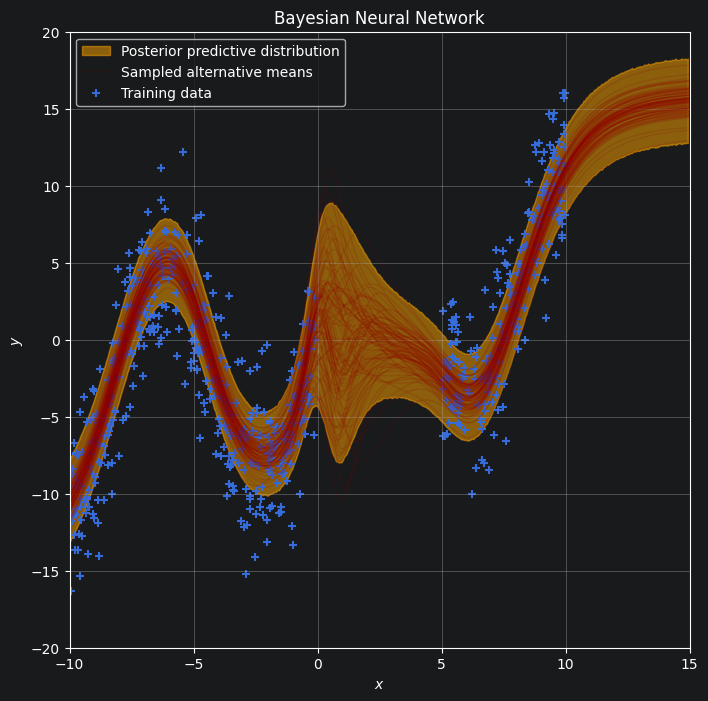

In [7]:
# Draw posterior predictive samples (replaces pyro.infer.Predictive)
predictive = Predictive(model, guide=guide, num_samples=5000, params=params_svi)
rng_key_pred = jax.random.PRNGKey(1)
svi_samples = predictive(rng_key_pred, NHIDDEN, x_test, None)

# Convert JAX arrays to numpy for plotting (replaces .detach().numpy())
y_preds = np.array(svi_samples['y']).squeeze()
y_mean  = np.mean(y_preds, axis=0)
y_sigma = np.std(y_preds,  axis=0)

plt.figure(figsize=(8, 8))
plt.fill_between(np.array(x_test).ravel(),
                 y_mean + 2 * y_sigma, y_mean - 2 * y_sigma,
                 alpha=0.5, color='orange',
                 label="Posterior predictive distribution")

# Sampled means
y_predictive_mean = np.array(svi_samples['predictive_mean']).squeeze()
for i in range(min(100, y_predictive_mean.shape[0])):
    plt.plot(np.array(x_test), y_predictive_mean[i],
             color='darkred', linewidth=1, alpha=.15,
             label="Sampled alternative means" if not i else None)

plt.scatter(np.array(x_train), np.array(y_train), marker='+', label="Training data")
plt.xticks(np.arange(-10, 16, 5))
plt.yticks(np.arange(-20, 21, 5))
plt.title('Bayesian Neural Network')
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.xlim([-10, 15])
plt.ylim([-20, 20])
plt.grid(True, "both")

### <span style="color:red">Optional</span> exercise:  Fix the variance

If you want to dig more into this in your own time, then consider the variance of the variable $y$ in the above model. It was assumed fixed at $\sigma=1$ (a pooor choice since $\sigma=3$ was used when we sampled the data) when we said that
``y = pyro.sample("y", pyro.distributions.Normal(loc=predictive_mean, scale=1.).to_event(1), obs=y_train)``.

There are several ways to improve on this (beyond "cheating" and hardcoding that $\sigma=3$):

1. Introduce a Pyro parameter to learn the variance. **Hint:** Initialize with a very small value.

2. Introduce a Pryro random variable to represent the variance, and find its posterior. **Hint:** Initialize the guide's random variable with a very small value.

3. Make the variance dependent of the input data by learning a model that outputs $\log\sigma$ as a function of $x$.


Evaluate the output for all cases and compare with the previous results.
